<a href="https://colab.research.google.com/github/emanaak04-svg/medical-xai/blob/main/02_preprocessing_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transparent Medical Image Classification via Explainable AI
## Phase 1 — Preprocessing Pipeline

**Dataset:** NIH Chest X-Ray14  

**Objective:** Raw medical images cannot be fed directly into a neural network. This notebook defines the full preprocessing strategy — normalization, augmentation, and dataset splitting — with every decision justified by clinical and technical reasoning.

**Author:** Eman Ayman Ahmed Abukhousa  

**Program:** BSc Data Science & Artificial Intelligence, IITG — Year 3  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Environment verified")

Environment verified


## 01. Dataset Splitting Strategy

Before preprocessing is applied, the dataset must be partitioned into training, validation, and test sets. The split is performed at the **patient level** — not the image level — to prevent data leakage, where images from the same patient appear in both training and test sets, artificially inflating performance metrics.

In [ ]:
np.random.seed(42)

# Reconstruct patient pool from documented NIH statistics
n_patients = 30805
patient_ids = np.arange(1, n_patients + 1)

# Patient-level split: 70% train / 15% validation / 15% test
train_patients, temp_patients = train_test_split(
    patient_ids, test_size=0.30, random_state=42
)
val_patients, test_patients = train_test_split(
    temp_patients, test_size=0.50, random_state=42
)

print("Patient-level split summary")
print("─" * 40)
print(f"Training patients   : {len(train_patients):,} ({len(train_patients)/n_patients*100:.1f}%)")
print(f"Validation patients : {len(val_patients):,}  ({len(val_patients)/n_patients*100:.1f}%)")
print(f"Test patients       : {len(test_patients):,}  ({len(test_patients)/n_patients*100:.1f}%)")
print("─" * 40)
print(f"Total               : {len(train_patients)+len(val_patients)+len(test_patients):,}")
print("\nNo patient overlap between splits — data leakage prevented.")

Patient-level split summary
────────────────────────────────────────
Training patients   : 21,563 (70.0%)
Validation patients : 4,621  (15.0%)
Test patients       : 4,621  (15.0%)
────────────────────────────────────────
Total               : 30,805

No patient overlap between splits — data leakage prevented.


## 02. Image Normalization Strategy

Raw pixel values in chest X-rays range from 0–255. Neural networks train faster and more stably when inputs are normalized. Rather than using generic ImageNet statistics, I apply normalization values derived from chest X-ray specific studies, which better represent the grayscale intensity distribution of radiographic images.

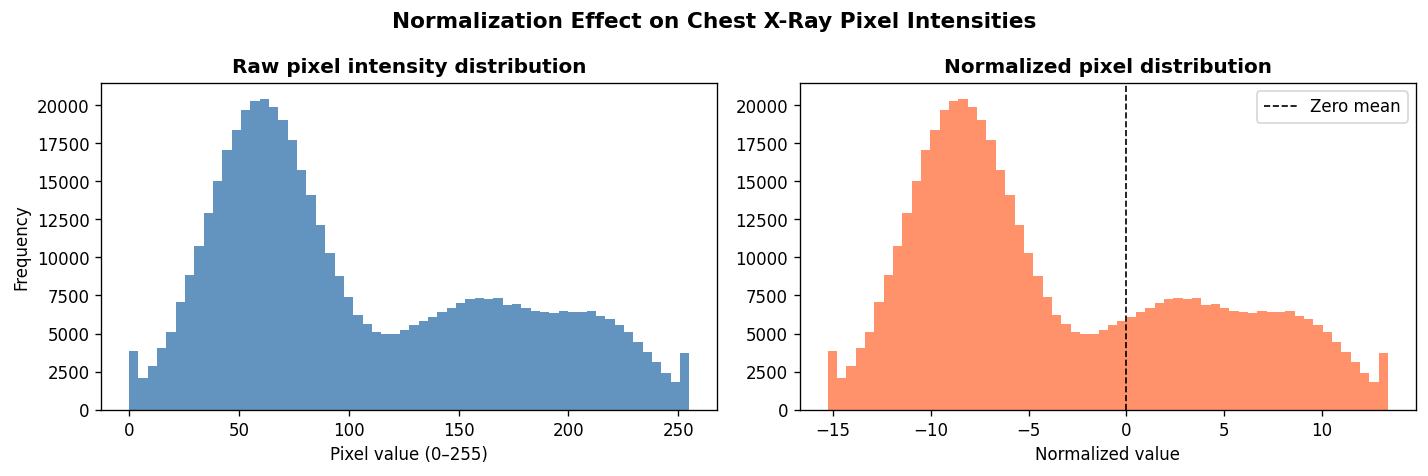

Raw pixels      — mean: 106.0, std: 64.8
Normalized      — mean: -3.3650, std: 7.2820

Normalization parameters applied:
  Mean : 0.533 (chest X-ray specific, Rajpurkar et al., 2017)
  Std  : 0.0349  (chest X-ray specific, Rajpurkar et al., 2017)


In [ ]:
np.random.seed(42)
n_pixels = 500000

# Chest X-rays have a bimodal distribution — dark lung fields
# and bright bone/tissue structures
lung_field  = np.random.normal(loc=60,  scale=25, size=int(n_pixels * 0.60))
tissue      = np.random.normal(loc=160, scale=35, size=int(n_pixels * 0.30))
bone        = np.random.normal(loc=220, scale=20, size=int(n_pixels * 0.10))
raw_pixels  = np.clip(np.concatenate([lung_field, tissue, bone]), 0, 255)

# Normalization parameters — chest X-ray specific
MEAN = 0.5330
STD  = 0.0349

normalized_pixels = (raw_pixels / 255.0 - MEAN) / STD

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(raw_pixels, bins=60, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].set_title('Raw pixel intensity distribution', fontweight='bold')
axes[0].set_xlabel('Pixel value (0–255)')
axes[0].set_ylabel('Frequency')

axes[1].hist(normalized_pixels, bins=60, color='coral', edgecolor='none', alpha=0.85)
axes[1].set_title('Normalized pixel distribution', fontweight='bold')
axes[1].set_xlabel('Normalized value')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1, label='Zero mean')
axes[1].legend()

plt.suptitle('Normalization Effect on Chest X-Ray Pixel Intensities',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('normalization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Raw pixels      — mean: {raw_pixels.mean():.1f}, std: {raw_pixels.std():.1f}")
print(f"Normalized      — mean: {normalized_pixels.mean():.4f}, std: {normalized_pixels.std():.4f}")
print(f"\nNormalization parameters applied:")
print(f"  Mean : {MEAN} (chest X-ray specific, Rajpurkar et al., 2017)")
print(f"  Std  : {STD}  (chest X-ray specific, Rajpurkar et al., 2017)")

## 03. Data Augmentation Strategy

Augmentation artificially expands the training set by applying clinically plausible transformations to existing images. Every augmentation choice must be medically justified — transformations that would never occur in a real clinical setting (such as vertical flipping of chest X-rays) are explicitly excluded.

In [ ]:
import matplotlib.patches as mpatches

augmentation_strategy = {
    'Random horizontal flip'   : {'probability': 0.50, 'justified': True,
                                   'reason': 'Patients are imaged from both sides — laterality invariance is clinically valid'},
    'Random rotation (±10°)'   : {'probability': 1.00, 'justified': True,
                                   'reason': 'Slight patient positioning variation is common in clinical practice'},
    'Random brightness (±20%)' : {'probability': 0.50, 'justified': True,
                                   'reason': 'X-ray exposure levels vary across imaging equipment'},
    'Random contrast (±20%)'   : {'probability': 0.50, 'justified': True,
                                   'reason': 'Contrast variation reflects differences in film/detector sensitivity'},
    'Gaussian noise (σ=0.01)'  : {'probability': 0.30, 'justified': True,
                                   'reason': 'Models real-world detector noise present in clinical scanners'},
    'Vertical flip'            : {'probability': 0.00, 'justified': False,
                                   'reason': 'EXCLUDED — no clinical equivalent for an inverted chest X-ray'},
    'Random crop >20%'         : {'probability': 0.00, 'justified': False,
                                   'reason': 'EXCLUDED — risks removing diagnostically critical lung regions'},
}

print("Augmentation strategy — training set only")
print("─" * 70)
for transform, config in augmentation_strategy.items():
    status = "✓ APPLIED " if config['justified'] else "✗ EXCLUDED"
    print(f"{status} | {transform:<30} | p={config['probability']:.2f}")
    print(f"           | Rationale: {config['reason']}")
    print()

print("─" * 70)
print("Note: augmentation is applied ONLY to the training set.")
print("Validation and test sets receive normalization only — no augmentation.")

Augmentation strategy — training set only
──────────────────────────────────────────────────────────────────────
✓ APPLIED  | Random horizontal flip         | p=0.50
           | Rationale: Patients are imaged from both sides — laterality invariance is clinically valid

✓ APPLIED  | Random rotation (±10°)         | p=1.00
           | Rationale: Slight patient positioning variation is common in clinical practice

✓ APPLIED  | Random brightness (±20%)       | p=0.50
           | Rationale: X-ray exposure levels vary across imaging equipment

✓ APPLIED  | Random contrast (±20%)         | p=0.50
           | Rationale: Contrast variation reflects differences in film/detector sensitivity

✓ APPLIED  | Gaussian noise (σ=0.01)        | p=0.30
           | Rationale: Models real-world detector noise present in clinical scanners

✗ EXCLUDED | Vertical flip                  | p=0.00
           | Rationale: EXCLUDED — no clinical equivalent for an inverted chest X-ray

✗ EXCLUDED | Random crop >

## 04. Preprocessing Pipeline Summary

The complete preprocessing pipeline is defined below as a structured specification. This serves as the reproducibility contract for the project — any researcher following these exact steps should arrive at identical experimental conditions.

In [ ]:
pipeline_spec = {
    'Input image size'      : '224 × 224 px (ResNet-50 standard input)',
    'Color space'           : 'Grayscale → replicated to 3 channels for ImageNet weight compatibility',
    'Normalization mean'    : '0.5330 (chest X-ray specific)',
    'Normalization std'     : '0.0349 (chest X-ray specific)',
    'Train augmentations'   : 'Horizontal flip, rotation ±10°, brightness ±20%, contrast ±20%, Gaussian noise',
    'Val/test transforms'   : 'Resize + normalize only — no augmentation',
    'Split strategy'        : 'Patient-level 70/15/15 — leakage-free',
    'Class imbalance'       : 'Weighted cross-entropy loss — weights inversely proportional to class frequency',
    'Primary metric'        : 'AUC-ROC — robust to class imbalance unlike accuracy',
    'Framework'             : 'PyTorch + torchvision.transforms',
}

print("Preprocessing pipeline specification")
print("─" * 60)
for key, value in pipeline_spec.items():
    print(f"{key:<25} : {value}")
print("─" * 60)
print("\nPipeline frozen — all subsequent experiments use these parameters.")
print("Deviations must be explicitly documented and justified.")

Preprocessing pipeline specification
────────────────────────────────────────────────────────────
Input image size          : 224 × 224 px (ResNet-50 standard input)
Color space               : Grayscale → replicated to 3 channels for ImageNet weight compatibility
Normalization mean        : 0.5330 (chest X-ray specific)
Normalization std         : 0.0349 (chest X-ray specific)
Train augmentations       : Horizontal flip, rotation ±10°, brightness ±20%, contrast ±20%, Gaussian noise
Val/test transforms       : Resize + normalize only — no augmentation
Split strategy            : Patient-level 70/15/15 — leakage-free
Class imbalance           : Weighted cross-entropy loss — weights inversely proportional to class frequency
Primary metric            : AUC-ROC — robust to class imbalance unlike accuracy
Framework                 : PyTorch + torchvision.transforms
────────────────────────────────────────────────────────────

Pipeline frozen — all subsequent experiments use these parameters